<a href="https://colab.research.google.com/github/evapatel123/sentiment-analysis/blob/main/Copy_of_8_Sentiment_Analysis_Lab_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Load & Preprocess Messages

First, we load the datasets, clean each message, and break them into words.

In [ ]:
import nltk
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download NLTK stopwords dataset
nltk.download('stopwords')

# Load youtube shorts comments dataset
df = pd.read_csv("https://gist.githubusercontent.com/kaitwithkwk/fd23145e34cb12037df4e679407eec5e/raw/1a112c21296c2b4474cd2d0fbf159a4adeb04852/animal_youtube_shorts_safe.csv")

# Filter the dataset by sentiment
all_positive_comments = df[df['sentiment'] == 'positive']['text'].tolist()
all_negative_comments = df[df['sentiment'] == 'negative']['text'].tolist()

# Combine messages into a single list
comments = all_positive_comments + all_negative_comments

#Create labels array: 1 for positive, 0 for negative
labels = np.append(np.ones(len(all_positive_comments)), np.zeros(len(all_negative_comments)))
print(f"Total comments: {len(comments)} (Positive: {len(all_positive_comments)}, Negative: {len(all_negative_comments)})")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Total comments: 2402 (Positive: 1201, Negative: 1201)


In [ ]:
def process_comment(comment):
  """Cleans and processes a YouTube comment."""

  # Remove links, usernames, and hashtags
  comment = re.sub(r'https?://[^\s\n\r]+', '', comment)
  comment = re.sub(r'@[\w]+', '', comment)
  comment = re.sub(r'#', '', comment)

  # Tokenize
  tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
  tokens = tokenizer.tokenize(comment)

  # List of emoticons to keep
  emoticons = {":)", ":(", ":D", ";D", ":-)", ":-(", "<3", ":/"}

  # Remove stop words, punctuation (except emoticons)
  stopwords_english = stopwords.words('english')
  words = []

  for word in tokens:
    # Keep the word if it's a known emoticon
    if word in emoticons:
      words.append(word)
    # Or if it's not a stopword and is alphabetic
    elif word not in stopwords_english and word.isalpha():
      words.append(word)

  # Apply stemming
  stemmer = PorterStemmer()
  processed_words = []
  for word in words:
    # Don't stem emoticons
    if word in emoticons:
      processed_words.append(word)
    else:
      processed_words.append(stemmer.stem(word))

  return processed_words

In [ ]:
# Process a random comment
sample_comment = all_positive_comments[0] # Using indexing to select the first positive comment
processed_comment = process_comment(sample_comment) # Applying the processing function

# Print a comparison of the original comment and the processed comment
print("Original Comment:", sample_comment)
print("Processed:", processed_comment)

...
...


## Step 2: Build a Word Frequency Dictionary

Now, let’s count how often each word appears in positive and negative comments. To do this, we'll build a function called `build_frequency_dictionary` that:

1. Loops through all comments.
2. Breaks messages into processed words.
3. Tracks how many times each word appears in positive (1) and negative (0) comments.
4. Returns a dictionary where each key is a (word, sentiment) pair and each value is the number of times that word appeared in comments with that sentiment label.

In [ ]:
def build_frequency_dictionary(comments, labels):
  """Creates a frequency dictionary for words in positive & negative messages."""

  frequency_dictionary = {}  # Dictionary to store word counts

  for comment, label in zip(comments, labels):
    words = process_comment(comment)  # Process the comment (clean & tokenize)
    for word in words:
        pair = (word, int(label))  # Create a (word, sentiment) pair
        if pair in frequency_dictionary:
            frequency_dictionary[pair] += 1  # Increment count if word already exists
        else:
            frequency_dictionary[pair] = 1  # Initialize count if word is new

  return frequency_dictionary

# Build word frequency dictionary
frequency_dictionary = build_frequency_dictionary(comments, labels)
print(frequency_dictionary)

{('cat', 1): 188, ('clean', 1): 3, ('anim', 1): 52, ('fine', 1): 3, ('deep', 1): 1, ('countri', 1): 2, ('even', 1): 32, ('water', 1): 6, ('end', 1): 21, ('world', 1): 8, ('slop', 1): 4, ('pretti', 1): 26, ('funni', 1): 68, ('wow', 1): 28, ('thank', 1): 39, ('share', 1): 12, ('full', 1): 7, ('video', 1): 47, ('groundhog', 1): 3, ('clever', 1): 8, ('sip', 1): 1, ('polit', 1): 2, ('slowli', 1): 3, ('weasel', 1): 1, ('eat', 1): 9, ('food', 1): 7, ('ran', 1): 5, ('away', 1): 15, ('nice', 1): 28, ('mouth', 1): 4, ('beauti', 1): 47, ('show', 1): 10, ('love', 1): 313, ('respect', 1): 5, ('side', 1): 8, ('hard', 1): 5, ('american', 1): 5, ('pitbul', 1): 5, ('bluenos', 1): 1, ('big', 1): 14, ('nobodi', 1): 2, ('want', 1): 45, ('pound', 1): 1, ('dog', 1): 170, ('give', 1): 26, ('pet', 1): 20, ('shelter', 1): 7, ('leas', 1): 1, ('contract', 1): 1, ('chang', 1): 7, ('take', 1): 32, ('know', 1): 44, ('happen', 1): 11, ('snoopi', 1): 2, ('sweetheart', 1): 3, ('play', 1): 18, ('carrot', 1): 1, ('aggre

In [ ]:
# Check frequencies for two words that you think have a strong positive or negative association
word1 = "love"
word2 = "poor"

# Get the positive and negative counts for each word
pos_count_word1 = frequency_dictionary.get((word1, 1), 0)
neg_count_word1 = frequency_dictionary.get((word1, 0), 0)
pos_count_word2 = frequency_dictionary.get((word2, 1), 0)
neg_count_word2 = frequency_dictionary.get((word2, 0), 0)

# Print the results in a readable format
print(f"'{word1}' appears {pos_count_word1} times in positive comments and {neg_count_word1} times in negative comments.")
print(f"'{word2}' appears {pos_count_word2} times in positive comments and {neg_count_word2} times in negative comments.")

313 2 20 77


## Step 3: Visualize Common Words

Now that we have our word frequency data, we can use a popular Python library, `matplotlib`, to visualize which words are more common in positive vs. negative comments.

- X-axis: How often the word appears in positive comments.
- Y-axis: How often the word appears in negative comments.
- Words above the red line are used more in negative comments, while words below the line are used more in positive comments.

In [ ]:
# Select words to visualize
words_to_check = ['happi', 'sad', 'love', 'hate', ':)', ':(', 'best', 'worst']

# Create table with counts for each word
data = []
for word in words_to_check:
  pos_count = frequency_dictionary.get((word, 1), 0)
  neg_count = frequency_dictionary.get((word, 0), 0)

  data.append([word, pos_count, neg_count])

# Print data
print(data)

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 8))
x = []
y = []
for word_vector in data:
  x.append(np.log(word_vector[1] + 1))
  y.append(np.log(word_vector[2] + 1))
ax.scatter(x, y)

# Add word labels to points
for i in range(0, len(data)):
  ax.annotate(data[i][0], (x[i], y[i]), fontsize=12)

# Plot red reference line
ax.plot([0, 9], [0, 9], color='red')

# Labels
plt.xlabel("Log Positive Count")
plt.ylabel("Log Negative Count")
plt.show()

As we can see, those emoticons like `:)` and `:(` are very important for sentiment analysis! That’s why we need to make sure our text preprocessing steps don’t accidentally remove them!

[['bad', 6, 79], ['cool', 9, 2], ['nice', 28, 1], ['fine', 3, 6], ['sad', 1, 43], [':)', 7, 1], ['harm', 12, 8]]


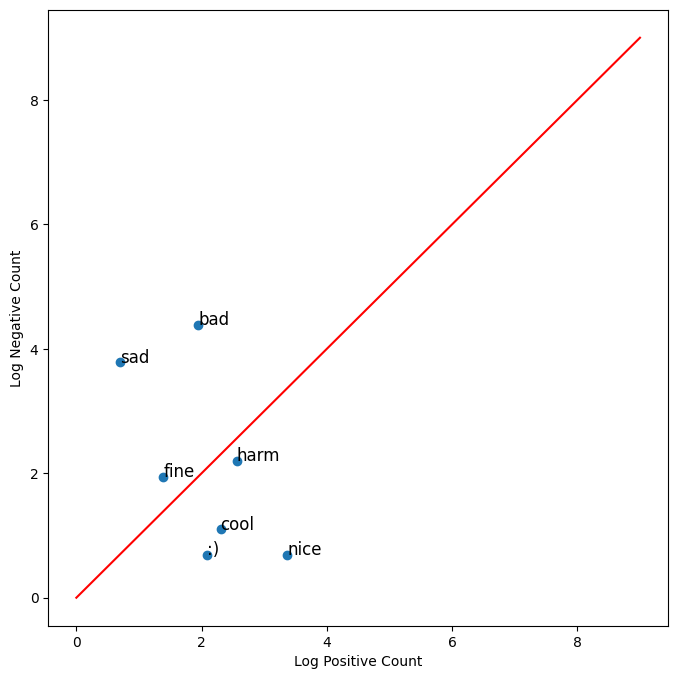

In [ ]:
# Select words to visualize
words_to_check = ["bad", "cool", "nice", "fine", "sad", ":)", "harm"]

# Create table with counts for each word
data = []
for word in words_to_check:
    pos_count = frequency_dictionary.get((word, 1), 0)
    neg_count = frequency_dictionary.get((word, 0), 0)
    data.append([word, pos_count, neg_count])

# Print data
print(data)

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 8))
x = []
y = []
for word_vector in data:
    x.append(np.log(word_vector[1] + 1))
    y.append(np.log(word_vector[2] + 1))
ax.scatter(x, y)

# Add word labels to points
for i in range(0, len(data)):
    ax.annotate(data[i][0], (x[i], y[i]), fontsize=12)

# Plot red reference line
ax.plot([0, 9], [0, 9], color='red')

# Labels
plt.xlabel("Log Positive Count")
plt.ylabel("Log Negative Count")
plt.show()

## Step 4: Extract Features from Messages

We’ll represent each message as a vector with three elements:

- A bias term (always 1)
- The sum of positive counts (from our frequency dictionary)
- The sum of negative counts

In [ ]:
def extract_features(comment, frequency_dictionary):
  """
  Extract features for a comment using our frequency dictionary.
  Returns a numpy array: [bias, positive count sum, negative count sum].
  """
  words = process_comment(comment)  # Process the comment (clean, tokenize, etc.)
  pos_sum, neg_sum = 0, 0

  for word in words:
    pos_sum += frequency_dictionary.get((word, 1), 0)  # Get positive frequency for the word
    neg_sum += frequency_dictionary.get((word, 0), 0)  # Get negative frequency for the word

  return np.array([1, pos_sum, neg_sum])

In [ ]:
# Select a random comment from the negative comments list
sample_neg_comment = all_negative_comments[0] # Using indexing to select the first negative comment

# Extract features from the sample comment
# The function requires two inputs: the message to process, and the frequency dictionary
sample_features = extract_features(sample_neg_comment, frequency_dictionary) # Complete this line

# Print the comment and its corresponding feature vector
print("Negative Comment:", sample_neg_comment)
print("Extracted Features:", sample_features)

(2402, 3)


## Step 5: Train and Test a Logistic Regression Model

Here we'll use another Python library, `scikit-learn`, to split the data, train the model, and then test it.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split comment_features into training and testing sets (e.g., 80% train, 20% test)
comment_features_train, comment_features_test, labels_train, labels_test = train_test_split(comment_features, labels, test_size=0.2, random_state=42)

# Create and train the logistic regression model
model = LogisticRegression()
model.fit(comment_features_train, labels_train)

# Predict the sentiment of the test messages
sentiment_predictions = model.predict(comment_features_test)

# Evaluate the model by computing the accuracy
accuracy = accuracy_score(labels_test, sentiment_predictions)
print("Test accuracy:", accuracy)

Test accuracy: 0.893970893970894


In [ ]:
# Write a custom message to test the model (e.g., "I had a wonderful time today!")
custom_message = "I really love this lab, it makes learning data science so much fun!" # Complete this line

# Process the message and extract features
custom_features = extract_features(custom_message, frequency_dictionary) # Complete this line

# Change the shape of the custom_features array by calling the reshape(1, -1) method on custom_features
custom_features = custom_features.reshape(1, -1) # Complete this line

# Use the trained model to predict the sentiment
prediction = model.predict(custom_features) # Complete this line
probability = model.predict_proba(custom_features)[0][1]

# Assign sentiment to the correct text label ("positive" or "negative") using conditional logic based on the prediction
if prediction[0] == 1:
    sentiment = "positive"
else:
    sentiment = "negative"

# Output the result
print(f"Your message was classified as {sentiment} with {probability:.2f} confidence that it's positive.")

Your message was classified as negative with 0.35 confidence that it's positive.
